--- Dataset Head ---
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

--- Model Evaluation ---
Mean Absolute Error (MAE): 0.64
R-squared Score (R²): 0.96


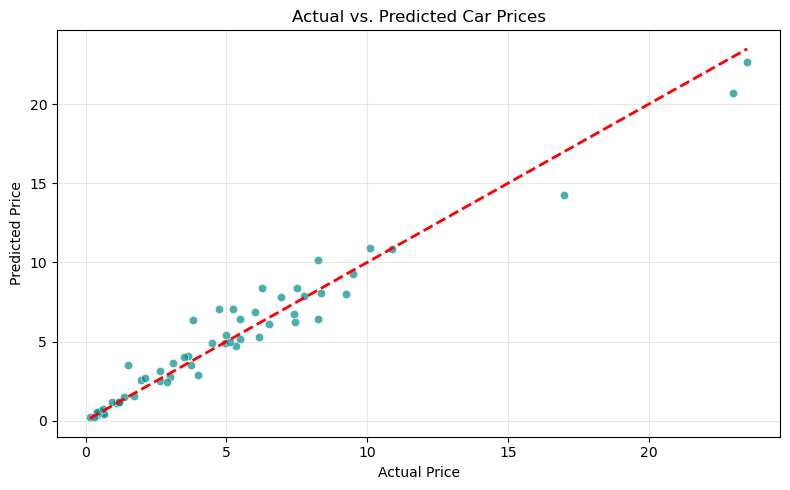

C:\Users\suloc\AppData\Local\Temp\ipykernel_20652\614678970.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_importances.values, y=model_importances.index, palette="mako")


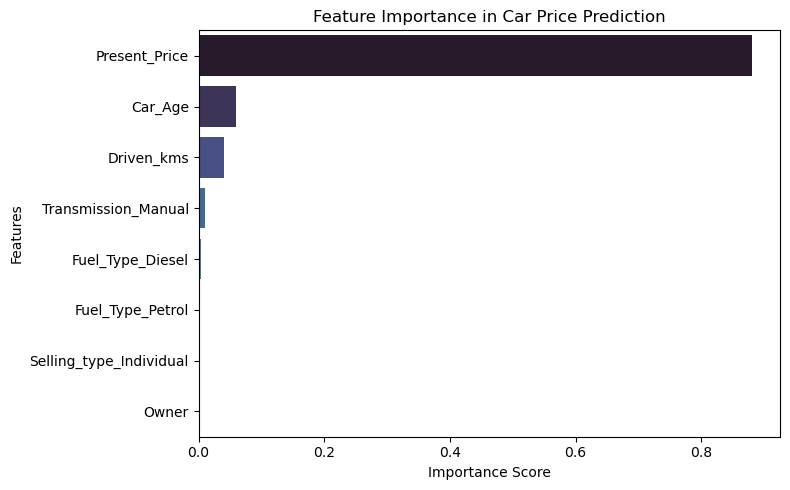

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load the Dataset
# Standard Kaggle file name is often 'car data.csv'
try:
    df = pd.read_csv(r'\Users\suloc\Downloads\archive (1)\car data.csv')
except FileNotFoundError:
    df = pd.read_csv("CarPrice_Assignment.csv")  # Common alternative

print("--- Dataset Head ---")
print(df.head())

# 2. Feature Engineering & Preprocessing
# Calculate age of the car to turn 'Year' into a more useful continuous feature
current_year = 2026
df["Car_Age"] = current_year - df["Year"]
df.drop("Year", axis=1, inplace=True)

# 'Car_Name' can serve as a proxy for Brand Goodwill. Let's ensure text consistency.
df["Car_Name"] = df["Car_Name"].str.lower().str.strip()

# One-Hot Encoding for categorical features (Fuel_Type, Selling_type, Transmission)
df_encoded = pd.get_dummies(
    df, columns=["Fuel_Type", "Selling_type", "Transmission"], drop_first=True
)

# 3. Splitting Features and Target Variable
# Target: Selling_Price (the price we want to predict)
X = df_encoded.drop(["Car_Name", "Selling_Price"], axis=1)
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Model Training
# Random Forest Regressor handles non-linear relationships well without requiring feature scaling
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predictions and Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared Score (R²): {r2:.2f}")

# 6. Data Visualization

# Plot 1: Actual vs Predicted Prices
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="darkcyan")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
)
plt.title("Actual vs. Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Feature Importance (Which features drive price the most?)
importances = model.feature_importances_
feature_names = X.columns
model_importances = pd.Series(importances, index=feature_names).sort_values(
    ascending=False
)

plt.figure(figsize=(8, 5))
sns.barplot(x=model_importances.values, y=model_importances.index, palette="mako")
plt.title("Feature Importance in Car Price Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()